In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tftinsights
import tftinsights.data

In [20]:
df = tftinsights.data.get_tft_dataset(include_traits  =True, include_units =True, include_items=True,include_engineered_features=True,include_player_data=False)  
y = df['placement'].astype(float) #dependent variable
x = df.drop(columns='placement') #independent variables 

x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

In [21]:
df

,item_TFT14_Item_ArmorcladEmblemItem,item_TFT14_Item_BallistekEmblemItem,item_TFT14_Item_BruiserEmblemItem,item_TFT14_Item_ControllerEmblemItem,item_TFT14_Item_CutterEmblemItem,item_TFT14_Item_DarkWebEmblemItem,item_TFT14_Item_DivinicorpEmblemItem,item_TFT14_Item_EdgeRunnerEmblemItem,item_TFT14_Item_GuardianEmblemItem,item_TFT14_Item_ImmortalEmblemItem,...,cost_count_2,cost_count_3,cost_count_4,cost_count_5,max_star_cost_1,max_star_cost_2,max_star_cost_3,max_star_cost_4,max_star_cost_5,placement
9,0,0,0,0,0,0,0,0,0,0,...,1,2,3,1,3,2,2,2,2,1
10,0,0,0,0,0,0,0,0,0,0,...,1,1,3,2,2,2,2,2,1,2
11,0,0,0,0,0,0,0,0,0,0,...,0,2,3,3,2,0,2,2,2,3
12,0,0,0,0,0,0,0,0,0,0,...,2,2,1,2,3,2,2,2,1,4
13,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,1,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111387,0,0,0,0,0,1,0,0,0,0,...,2,1,2,2,2,2,2,2,2,4
111388,0,0,0,0,0,0,0,0,0,0,...,2,3,0,0,2,3,3,0,0,5
111389,0,0,0,0,0,0,0,0,0,0,...,2,1,2,1,3,2,2,2,1,6
111390,0,0,0,0,0,0,0,0,0,0,...,3,1,3,0,2,2,1,2,0,7


In [22]:
#Normalize features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_val = scaler.transform(x_val)
print(x_train.shape[1])

264


In [23]:
model = keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    layers.Dense(64, activation=tf.nn.leaky_relu),
    layers.Dense(32, activation=tf.nn.leaky_relu),
    layers.Dense(1) 
])

In [24]:
model.compile(
    optimizer='adam',
    loss='mse',  # 'mean_squared_error' or 'mean_absolute_error'
    metrics=['mae']  # mean absolute error
)

In [25]:
from sklearn.metrics import r2_score
from tensorflow.keras.callbacks import Callback

#https://www.tensorflow.org/guide/keras/writing_your_own_callbacks
class R2Callback(Callback):
    def __init__(self, validation_data):
        self.validation_data = validation_data

    def on_epoch_end(self, epoch, logs=None):
        x_val, y_val = self.validation_data
        y_pred = self.model.predict(x_val, verbose=0)
        r2 = r2_score(y_val, y_pred)

        # Save to logs so it's stored in `history.history`
        if logs is not None:
            logs['val_r2'] = r2
            
        print(f"Epoch {epoch + 1}: val_R2 = {r2:.4f}")

# Create the callback
r2_callback = R2Callback(validation_data=(x_val, y_val))

# Fit the model with your explicit validation data
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[r2_callback]
)

Epoch 1/100
1316/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - loss: 4.3964 - mae: 1.5941Epoch 1: val_R2 = 0.5534
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 4.3448 - mae: 1.5849 - val_loss: 2.3407 - val_mae: 1.2185 - val_r2: 0.5534
Epoch 2/100
1340/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step - loss: 2.0832 - mae: 1.1500Epoch 2: val_R2 = 0.5990
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 2.0826 - mae: 1.1497 - val_loss: 2.1017 - val_mae: 1.1479 - val_r2: 0.5990
Epoch 3/100
1361/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - loss: 1.8804 - mae: 1.0872Epoch 3: val_R2 = 0.5636
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.8804 - mae: 1.0872 - val_loss: 2.2874 - val_mae: 1.1482 - val_r2: 0.5636
Epoch 4/100
1316/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - loss: 1.8308 - mae: 1.0633Epoch 4: val_R2 = 0.6234
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.8301 - mae: 1.0632 - val_loss: 1.9740 - val_mae: 1.1118 - val_r2: 0.6234
Epoch 5/100
1354/1368 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step

In [26]:
loss, mae = model.evaluate(x_test, y_test)
print(f"Test MAE: {mae}")

428/428 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - loss: 2.4754 - mae: 1.2333
Test MAE: 1.2513444423675537


In [27]:
from sklearn.metrics import r2_score

y_pred = model.predict(x_test)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

428/428 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step
R² Score: 0.5167602028726753


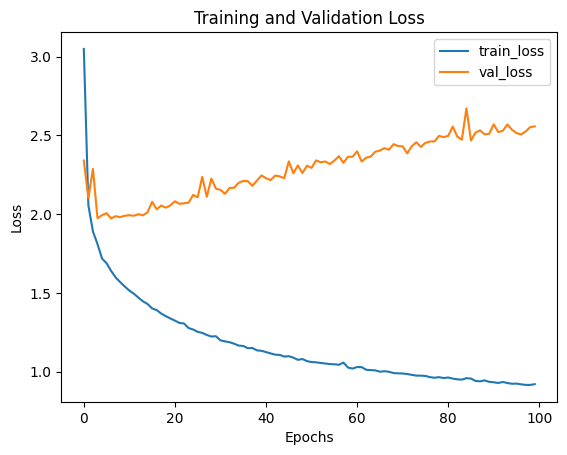

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

In [29]:
print ( max ( history.history['val_r2'] ))
print ( f"at epoch {np.argmax(history.history['val_r2']) + 1 }  ")

0.6235834235661957
at epoch 7  


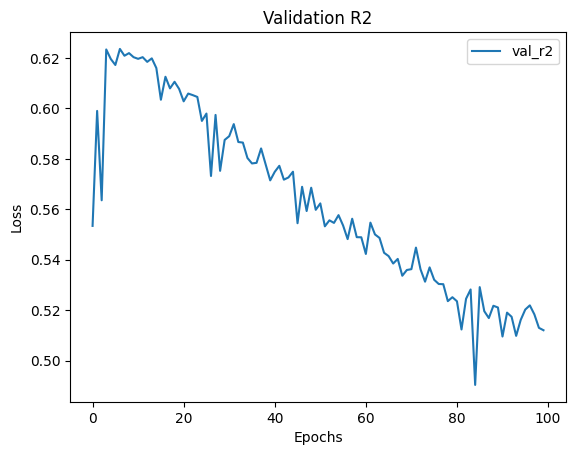

In [30]:
plt.plot(history.history['val_r2'], label='val_r2')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation R2")
plt.show()